In [1]:
# SMA - Simple Moving Average

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [64]:
df = pd.read_csv('/Users/sylvia/Desktop/Anomaly_Detection/Experiments/Data/real_15.csv', index_col = 'timestamp')

In [65]:
df.head()

,value,is_anomaly
timestamp,,
1,7350,0
2,6442,0
3,6057,0
4,7012,0
5,8847,0


[Text(0, 0.5, 'traffic - yahoo properties')]

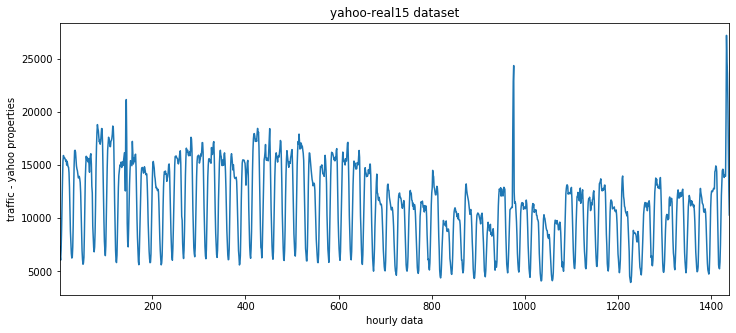

In [69]:
ax = df['value'].plot(figsize = (12,5), title = 'yahoo-real15 dataset');
ax.set(xlabel = 'hourly data')
ax.set(ylabel = 'traffic - yahoo properties')

In [42]:
df['value-24 hour SMA'] = df['value'].rolling(window = 24).mean()

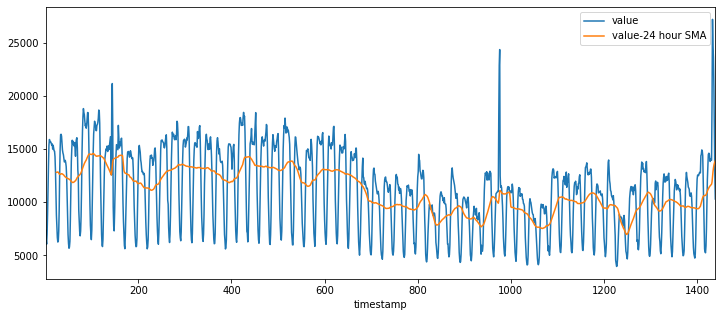

In [43]:
# More detailed behaviour, short window size
df[['value','value-24 hour SMA']].plot(figsize = (12,5));

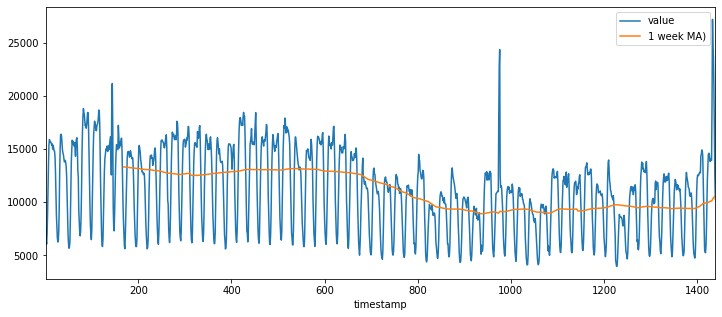

In [28]:
# Less detailed behaviour, large window size
df['1 week SMA)'] = df['value'].rolling(window = 168).mean()
df[['value','1 week SMA)']].plot(figsize = (12,5));

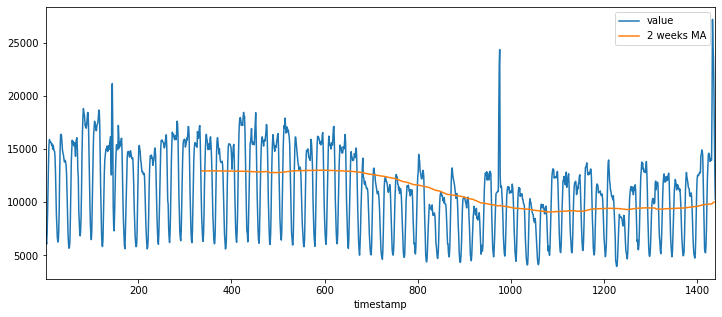

In [24]:
df['2 weeks SMA'] = df['value'].rolling(window = 336).mean()
df[['value','2 weeks SMA']].plot(figsize = (12,5));

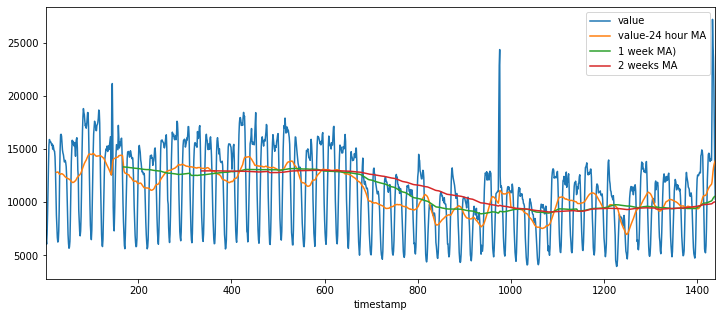

In [51]:
SMA_plot = df[['value','value-24 hour SMA','1 week SMA)', '2 weeks SMA']].plot(figsize = (12,5))
SMA_plot;

In [32]:
# EWMA Exponentially Weighted Moving Average
# REcent points more weight than the past points

In [33]:
# All plots in beginning have lag, can fix with EWMA, smaller windows more noise
# Seasonality trend is lot more clear towards end than towards the beginning points
# cz we weighted points closer to present heavier than older values

In [36]:
df['EWMA - 24 HOUR'] = df['value'].ewm(span=24).mean()

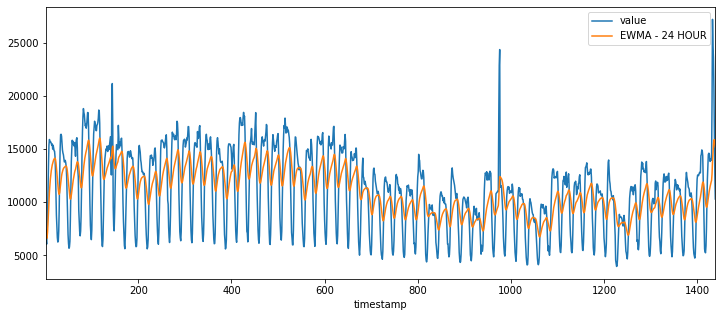

In [44]:
df[['value', 'EWMA - 24 HOUR']].plot(figsize = (12,5));

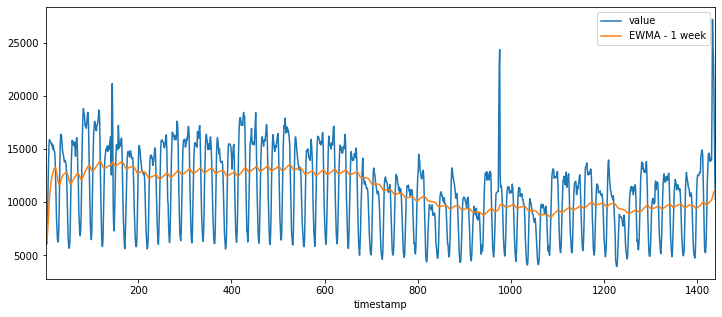

In [46]:
df['EWMA - 1 week'] = df['value'].ewm(span=168).mean()
df[['value','EWMA - 1 week']].plot(figsize = (12,5));

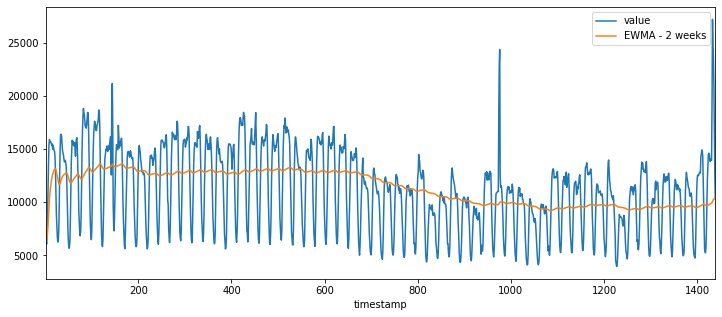

In [47]:
df['EWMA - 2 weeks'] = df['value'].ewm(span=336).mean()
df[['value','EWMA - 2 weeks']].plot(figsize = (12,5));

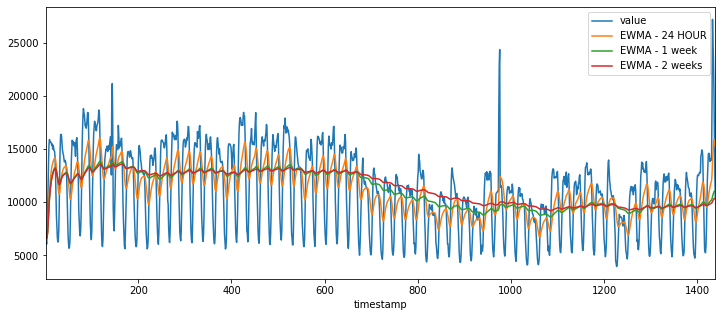

In [50]:
EWMA_plot = df[['value','EWMA - 24 HOUR','EWMA - 1 week','EWMA - 2 weeks']].plot(figsize = (12,5))
EWMA_plot;

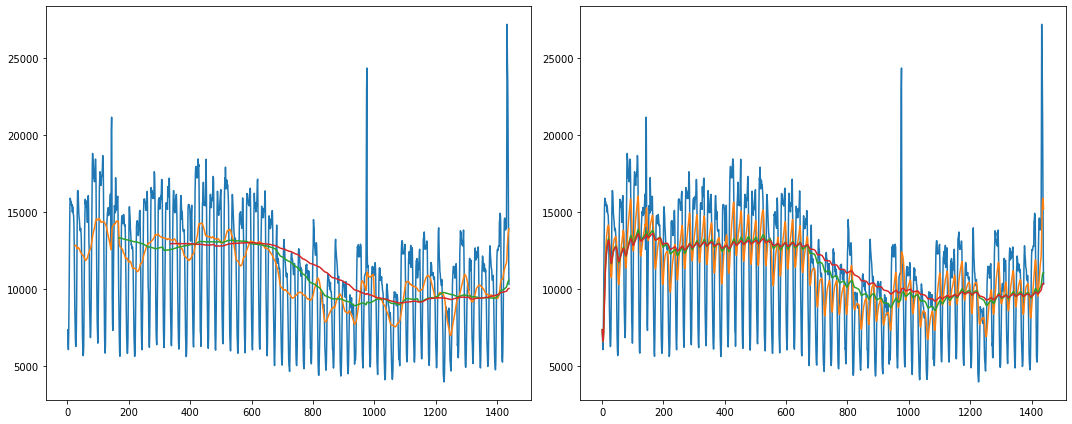

In [61]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
axes[0].plot(df[['value','value-24 hour SMA','1 week SMA)', '2 weeks SMA']])
axes[1].plot(df[['value','EWMA - 24 HOUR','EWMA - 1 week','EWMA - 2 weeks']])
fig.tight_layout()